In [1]:
!pip install pandas scikit-learn matplotlib

Decision Tree Model:
DecisionTreeClassifier()


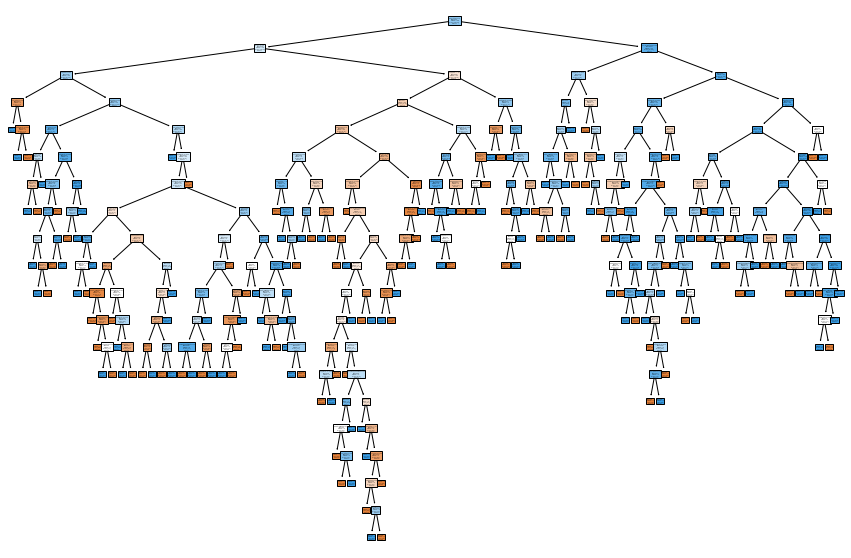


Evaluation Metrics:
Accuracy: 0.69
Correctly classified : 69.0 %
Wrongly Classified:  31.0 %
Mean Absolute Error: 0.31
Root Mean Squared Error: 0.5567764362830022


In [1]:
import pandas as pd
from scipy.io import arff
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

data, meta = arff.loadarff("credit-g.arff")

dataset = pd.DataFrame(data)

for column in dataset.columns:
    if dataset[column].dtype == object:
        dataset[column] = dataset[column].str.decode('utf-8')

label_encoder = LabelEncoder()

for column in dataset.columns:
    if dataset[column].dtype == 'object':
        dataset.loc[:, column] = label_encoder.fit_transform(dataset[column].astype(str))

X = dataset.drop('class', axis=1)
y = dataset['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Model:")
print(model)

plt.figure(figsize=(15, 10))

plot_tree(model, feature_names=list(X.columns), class_names=['0', '1'], filled=True)

plt.show()

print("\nEvaluation Metrics:")
print("Accuracy:", accuracy)

perc_crct = accuracy * 100
perc_wrong = 100 - perc_crct

print("Correctly classified :", perc_crct, "%")
print("Wrongly Classified: ", perc_wrong, "%")

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", mse ** 0.5)